# Countywide Structure Exposure Networks

This notebook maps the full spatial extent of the completed Los Angeles County OpenView 3D graph. It focuses on the overview panel of the regional SEN figure and compares two component definitions at the same pooled OpenView destruction-equivalent threshold: cumulative Top-2 first, followed by Every-Edge Above Threshold (EEAT). No fire arrival, ignition, or damage outcomes enter the regional component construction.

In [1]:
import os
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap, LogNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle
from shapely.geometry import box

cwd = Path.cwd().resolve()
PACKAGE_ROOT = next(
    path for path in [cwd, *cwd.parents]
    if (path / 'data').exists() and (path / 'src').exists()
    and (path / 'notebooks').exists()
)
sys.path.insert(0, str(PACKAGE_ROOT))

from src.analysis.fragility import fit_5pl
from src.analysis.openview_3d_sen import (
    audit_openview_3d_run, build_county_regional_sen,
    load_county_regional_sen_cache, save_county_regional_sen_cache,
)
from src.analysis.regional_sen import (
    regional_category_summary, regional_size_profile,
)
from src.analysis.sen import coupling_at_probability
from src.viz.regional_sen import (
    CMAP, INK, ISOLATED, OTHER, WUI, _draw_buildings, _full_interface,
)
from src.viz.style import apply_style

apply_style()
base_viridis = plt.colormaps['Spectral']
PUBLICATION_CMAP = LinearSegmentedColormap.from_list(
    'spectral_truncated', base_viridis(np.linspace(.05, .88, 256)),
)
SEN_SIZE_BOUNDS = np.array([1, 2, 5, 10, 25, 100, 500, 2049])

SEN_SIZE_COLORS = [
    "#D9D9D6",  # 1: isolated
    "#4575B4",  # 2–4
    "#74ADD1",  # 5–9
    "#ABD9E9",  # 10–24
    "#FEE090",  # 25–99
    "#F46D43",  # 100–499
    "#A50026",  # 500–2,048
]
SEN_SIZE_CMAP = mpl.colors.ListedColormap(
    SEN_SIZE_COLORS, name='sen_size_classes',
)
SEN_SIZE_NORM = mpl.colors.BoundaryNorm(
    SEN_SIZE_BOUNDS, SEN_SIZE_CMAP.N, clip=True,
)
SEN_SIZE_TICKS = (SEN_SIZE_BOUNDS[:-1] + SEN_SIZE_BOUNDS[1:]) / 2
SEN_SIZE_TICKLABELS = [
    '1', '2–4', '5–9', '10–24', '25–99', '100–499', '500–2,048',
]
WUI_PERIMETER_COLOR = '#3B78A3'
OPENVIEW_3D_RUN = Path(os.environ.get(
    'OPENVIEW_3D_BVF_DIR',
    '/Users/adamswietek/Documents/PostDoc/openview/results/lariac6_wui_all_2mi_bvf_3d_nf_cone85_nosolar_pads3m',
))
RUN_TAG = 'openview3d_lariac6_2mi'
DERIVED = PACKAGE_ROOT / 'data' / 'derived' / RUN_TAG
ANALYSIS_PATH = DERIVED / 'analysis_openview3d.parquet'
BUILDING_CACHE = DERIVED / 'county_buildings.parquet'
TOP2_MAP_CACHE = DERIVED / 'county_sen_top2_map_source.parquet'
TOP2_EDGE_FLOOR_ALPHA = 0.75
EEAT_MAP_CACHE = DERIVED / 'county_sen_eeat_map_source.parquet'
WUI_PATH = PACKAGE_ROOT / 'data' / 'calfire_wui_la.gpkg'
RESULTS = PACKAGE_ROOT / 'results' / RUN_TAG / 's2s_nc'
FIGURES = PACKAGE_ROOT / 'figures' / 's2s_nc/main'
for directory in (DERIVED, RESULTS, FIGURES):
    directory.mkdir(parents=True, exist_ok=True)

def regional_cache_matches(map_path, method, threshold, n_neighbors=None, edge_floor_fraction=None):
    component_path = map_path.with_name(
        f'{map_path.stem}_components.parquet'
    )
    summary_path = map_path.with_name(f'{map_path.stem}_summary.parquet')
    if not all(path.exists() for path in (map_path, component_path, summary_path)):
        return False
    try:
        cached = pd.read_parquet(summary_path).iloc[0]
    except (IndexError, OSError, ValueError):
        return False
    try:
        cached_n = cached.get('n_neighbors')
        n_matches = (
            pd.isna(cached_n) if n_neighbors is None
            else int(cached_n) == int(n_neighbors)
        )
        cached_floor = cached.get('edge_floor_fraction')
        floor_matches = (
            pd.isna(cached_floor) if edge_floor_fraction is None
            else np.isclose(float(cached_floor), edge_floor_fraction)
        )
        return (
            cached.get('clustering_method') == method
            and np.isclose(float(cached.get('F_ij_threshold')), threshold)
            and n_matches and floor_matches
        )
    except (TypeError, ValueError):
        return False

COUNTY_PLACES = {
    'Malibu': (-118.779, 34.026),
    'Santa Monica': (-118.490, 34.040),
    'Los Angeles': (-118.244, 34.052),
    'Altadena': (-118.136, 34.190),
    'Pasadena': (-118.145, 34.148),
}
WINDOW_NORTH = 34.2799
WINDOW_SOUTH = 34.0032
WINDOW_WEST = -118.6894
WINDOW_EAST = -118.0096
WINDOW_BOUNDS_LON_LAT = (
    WINDOW_WEST, WINDOW_SOUTH, WINDOW_EAST, WINDOW_NORTH,
)

def plot_county_overview(
    result, title, output_stem, *, bounds_lon_lat=None, show_summary=True,
):
    buildings = result['buildings']
    corridor = result['corridor']
    summary = result['summary'].iloc[0]
    interface = _full_interface(
        PACKAGE_ROOT, buildings.crs, corridor, wui=result['wui'],
    )
    spanning_sizes = buildings.loc[
        buildings.spans_interface_class, 'component_size'
    ]
    maximum = max(2, int(spanning_sizes.max()))
    size_scale_max = int(2 ** np.ceil(np.log2(maximum)))
    norm = LogNorm(vmin=2, vmax=size_scale_max)

    fig = plt.figure(figsize=(11.5, 5.8))
    ax = fig.add_axes([.035, .23, .93, .69])
    if bounds_lon_lat is None:
        xmin, ymin, xmax, ymax = buildings.total_bounds
        xpad = .012 * (xmax - xmin)
        ypad = .04 * (ymax - ymin)
        bounds = (xmin - xpad, xmax + xpad, ymin - ypad, ymax + ypad)
    else:
        projected_window = gpd.GeoSeries(
            [box(*bounds_lon_lat)], crs='EPSG:4326',
        ).to_crs(buildings.crs)
        xmin, ymin, xmax, ymax = projected_window.total_bounds
        bounds = (xmin, xmax, ymin, ymax)
    _draw_buildings(
        ax, buildings, norm, interface, corridor, bounds=bounds,
        labels=True, places_wgs84=COUNTY_PLACES,
    )
    ax.text(0, 1.025, 'a', transform=ax.transAxes, fontsize=9,
            fontweight='bold', va='bottom')
    ax.text(.027, 1.025, title, transform=ax.transAxes, fontsize=8.5,
            fontweight='bold', va='bottom')
    if show_summary:
        ax.text(
            .995, .975,
            f"{int(summary.interface_spanning_SENs):,} Interface-spanning SENs · "
            f"{100 * summary.share_in_interface_spanning_SENs:.1f}% of buildings\n"
            f"largest observed: {int(summary.largest_interface_spanning_SEN):,} "
            'buildings (screen-edge censored)',
            transform=ax.transAxes, ha='right', va='top', fontsize=5.7,
            linespacing=1.12, color=INK, clip_on=False,
        )
    ax.legend(handles=[
        Patch(facecolor=OTHER, edgecolor='none', label='other connected SEN'),
        Patch(facecolor=ISOLATED, edgecolor='none', label='isolated building'),
        Line2D([0], [0], color=WUI, lw=1.1, label='WUI Interface boundary'),
        Line2D([0], [0], color='#8B8B88', lw=.6, ls=(0, (2, 2)),
               label='combined WUI + 2-mile screen'),
    ], loc='upper left', bbox_to_anchor=(.002, .94), fontsize=5.8,
       labelspacing=.35, handlelength=1.4, frameon=True,
       facecolor='white', edgecolor='none', framealpha=.82)

    cbar_ax = fig.add_axes([.22, .09, .56, .024])
    cbar = fig.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=CMAP), cax=cbar_ax,
        orientation='horizontal',
    )
    ticks = 2 ** np.arange(1, int(np.log2(size_scale_max)) + 1, 2)
    if ticks[-1] != size_scale_max:
        ticks = np.append(ticks, size_scale_max)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([f'{value:,}' for value in ticks])
    cbar.set_label('Buildings in Interface-spanning SEN', fontsize=6.8)
    cbar.ax.tick_params(labelsize=6, length=2)

    stem = FIGURES / output_stem
    fig.savefig(stem.with_suffix('.pdf'), bbox_inches='tight', facecolor='white')
    fig.savefig(stem.with_suffix('.png'), dpi=600, bbox_inches='tight',
                facecolor='white')
    print('saved', stem.with_suffix('.png'))
    return fig

def plot_cluster_centroid_window(
    result, title, output_stem, bounds_lon_lat, *, method_label=None,
):
    buildings = result['buildings']
    mapped_wui = result['wui'].to_crs(buildings.crs)
    window = gpd.GeoSeries(
        [box(*bounds_lon_lat)], crs='EPSG:4326',
    ).to_crs(buildings.crs)
    window_geometry = window.iloc[0]
    xmin, ymin, xmax, ymax = window.total_bounds

    # Use the spatial index through .cx before computing centroids, then
    # impose the exact rule that the building centroid lies in the window.
    candidates = buildings.cx[xmin:xmax, ymin:ymax].copy()
    candidate_points = candidates.geometry.centroid
    inside = candidate_points.intersects(window_geometry)
    subset = candidates.loc[inside].copy()
    points = candidate_points.loc[inside]

    wui_perimeter = gpd.GeoSeries(
        [mapped_wui.geometry.union_all().boundary.intersection(window_geometry)],
        crs=buildings.crs,
    )
    fig, ax = plt.subplots(figsize=(7.2, 3.75))
    ax.scatter(
        points.x, points.y, c=subset.component_size,
        cmap=SEN_SIZE_CMAP, norm=SEN_SIZE_NORM,
        s=.24, linewidths=0, alpha=.90, rasterized=True, zorder=3,
    )
    # A pale under-stroke keeps the mapped-WUI perimeter visible over
    # every component-size color without competing with the data field.
    wui_perimeter.plot(ax=ax, color='white', linewidth=1.8, zorder=5)
    wui_perimeter.plot(
        ax=ax, color=WUI_PERIMETER_COLOR, linewidth=.7, zorder=6,
    )
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.text(0, 1.025, 'a', transform=ax.transAxes, fontsize=9,
            fontweight='bold', va='bottom')
    ax.text(.035, 1.025, title, transform=ax.transAxes, fontsize=8.5,
            fontweight='bold', va='bottom')
    if method_label:
        ax.text(.995, 1.025, method_label, transform=ax.transAxes,
                ha='right', va='bottom', fontsize=6.2, color='#5F5F5B')
    ax.legend(handles=[
        Line2D([0], [0], color=WUI_PERIMETER_COLOR, lw=1.15,
               label='Mapped WUI perimeter'),
    ], loc='upper left', fontsize=6, frameon=False, handlelength=1.7)

    cbar = fig.colorbar(
        plt.cm.ScalarMappable(norm=SEN_SIZE_NORM, cmap=SEN_SIZE_CMAP), ax=ax,
        orientation='horizontal', fraction=.030, pad=.030, aspect=60,
        boundaries=SEN_SIZE_BOUNDS, ticks=SEN_SIZE_TICKS, spacing='uniform',
    )
    cbar.set_ticklabels(SEN_SIZE_TICKLABELS)
    cbar.set_label('Connected-network size (buildings)', fontsize=6.8)
    cbar.ax.tick_params(labelsize=6, length=2)
    fig.subplots_adjust(left=.025, right=.985, top=.91, bottom=.08)

    stem = FIGURES / output_stem
    fig.savefig(stem.with_suffix('.pdf'), bbox_inches='tight', facecolor='white')
    fig.savefig(stem.with_suffix('.png'), dpi=600, bbox_inches='tight',
                facecolor='white')
    print('saved', stem.with_suffix('.png'))
    return fig, subset


## OpenView graph and common threshold

The regional maps use the same threshold as notebook 04, re-fit from the pooled exposed population in `analysis_openview3d.parquet`. The graph covers the union of all CAL FIRE WUI classes plus a two-mile buffer and retains the OpenView run's 152.4-m candidate radius.

In [2]:
input_audit = audit_openview_3d_run(OPENVIEW_3D_RUN)
analysis = pd.read_parquet(ANALYSIS_PATH)
exposed = analysis.loc[analysis.exposed.eq(1)]
pooled_fit = fit_5pl(exposed.F_destroyed_wmean, exposed.is_destroyed)
F_IJ_THRESHOLD = coupling_at_probability(pooled_fit, .50)
display(input_audit.T.rename(columns={0: 'value'}))
print(f'Common OpenView SEN threshold: F* = {F_IJ_THRESHOLD:.6f}')


,value
model,differential_area_3d
tiles,1815
buildings,1556752
candidate_pairs,26592049
maximum_pair_distance_m,152.4
wui_buffer_m,3218.688
terrain_resolution_m,5.0
source,/Users/adamswietek/Documents/PostDoc/data/raw_...


Common OpenView SEN threshold: F* = 0.055429


## Full extent — cumulative Top-2

For every building, the two strongest incident pairwise couplings are selected. A building qualifies when it has two distinct neighbors and $F_{i(1)} + F_{i(2)} \geq F^*$. Components use selected links whose endpoints both qualify and whose individual coupling satisfies $F_{ij} \geq 0.75F^*$. The stricter edge floor prevents weak links from piggybacking on a strong companion edge.

In [3]:
if regional_cache_matches(
    TOP2_MAP_CACHE, 'cumulative_top_2', F_IJ_THRESHOLD, n_neighbors=2,
    edge_floor_fraction=TOP2_EDGE_FLOOR_ALPHA,
):
    regional_top2 = load_county_regional_sen_cache(
        PACKAGE_ROOT, TOP2_MAP_CACHE, wui_path=WUI_PATH,
    )
    print(f'loaded cached Top-2 assignments: {TOP2_MAP_CACHE}')
else:
    regional_top2 = build_county_regional_sen(
        PACKAGE_ROOT, OPENVIEW_3D_RUN, F_IJ_THRESHOLD, BUILDING_CACHE,
        wui_path=WUI_PATH, n_neighbors=2,
        edge_floor_fraction=TOP2_EDGE_FLOOR_ALPHA,
    )
    save_county_regional_sen_cache(regional_top2, TOP2_MAP_CACHE)
    print(f'cached Top-2 assignments: {TOP2_MAP_CACHE}')
top2_summary = regional_top2['summary']
top2_components = regional_top2['components']
top2_size_profile = regional_size_profile(top2_components)
top2_categories = regional_category_summary(regional_top2['buildings'])
top2_summary.to_csv(RESULTS / 'county_sen_top2_summary.csv', index=False)
top2_components.to_csv(RESULTS / 'county_sen_top2_components.csv', index=False)
top2_size_profile.to_csv(
    RESULTS / 'county_sen_top2_size_profile.csv', index=False,
)
top2_categories.to_csv(
    RESULTS / 'county_sen_top2_category_summary.csv', index=False,
)
display(top2_summary.T.rename(columns={0: 'value'}))
display(top2_categories.round(4))


loaded cached Top-2 assignments: /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/data/derived/openview3d_lariac6_2mi/county_sen_top2_map_source.parquet


,value
corridor,Los Angeles County combined-WUI two-mile screen
clustering_method,cumulative_top_2
n_neighbors,2
edge_floor_fraction,0.75
screen_buffer_m,3218.688
F_ij_threshold,0.055429
P_destroyed_equivalent,0.5
buildings,1556752
excluded_structures,0
candidate_pairs,26592049


,network_category,buildings,building_share
0,Isolated,149255,0.0959
1,Other connected SEN,1345678,0.8644
2,Interface-spanning SEN,61819,0.0397


## Full extent — Every-Edge Above Threshold (EEAT)

EEAT retains every undirected pairwise edge satisfying $F_{ij} \geq F^*$ and forms connected components of the complete thresholded county graph.

In [4]:
if regional_cache_matches(
    EEAT_MAP_CACHE, 'EEAT', F_IJ_THRESHOLD, n_neighbors=None,
):
    regional_eeat = load_county_regional_sen_cache(
        PACKAGE_ROOT, EEAT_MAP_CACHE, wui_path=WUI_PATH,
    )
    print(f'loaded cached EEAT assignments: {EEAT_MAP_CACHE}')
else:
    regional_eeat = build_county_regional_sen(
        PACKAGE_ROOT, OPENVIEW_3D_RUN, F_IJ_THRESHOLD, BUILDING_CACHE,
        wui_path=WUI_PATH,
    )
    save_county_regional_sen_cache(regional_eeat, EEAT_MAP_CACHE)
    print(f'cached EEAT assignments: {EEAT_MAP_CACHE}')
eeat_summary = regional_eeat['summary']
eeat_components = regional_eeat['components']
eeat_size_profile = regional_size_profile(eeat_components)
eeat_categories = regional_category_summary(regional_eeat['buildings'])
eeat_summary.to_csv(RESULTS / 'county_sen_eeat_summary.csv', index=False)
eeat_components.to_csv(RESULTS / 'county_sen_eeat_components.csv', index=False)
eeat_size_profile.to_csv(
    RESULTS / 'county_sen_eeat_size_profile.csv', index=False,
)
eeat_categories.to_csv(
    RESULTS / 'county_sen_eeat_category_summary.csv', index=False,
)
display(eeat_summary.T.rename(columns={0: 'value'}))
display(eeat_categories.round(4))


loaded cached EEAT assignments: /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/data/derived/openview3d_lariac6_2mi/county_sen_eeat_map_source.parquet


,value
corridor,Los Angeles County combined-WUI two-mile screen
clustering_method,EEAT
n_neighbors,None
edge_floor_fraction,NaN
screen_buffer_m,3218.688
F_ij_threshold,0.055429
P_destroyed_equivalent,0.5
buildings,1556752
excluded_structures,0
candidate_pairs,26592049


,network_category,buildings,building_share
0,Isolated,209431,0.1345
1,Other connected SEN,1295735,0.8323
2,Interface-spanning SEN,51586,0.0331


## Santa Monica Mountains regional window

The following two cells use the same geographic window for a direct visual comparison of cumulative Top-2 and EEAT components: west $-118.6894$, east $-118.0096$, south $34.0032$, north $34.2799$. The bounds are transformed from WGS84 to the OpenView graph CRS. Every building whose centroid lies inside the window is drawn as a point and colored by its full countywide component size, including singleton and non-Interface-spanning SENs. The window does not cut or rebuild components. The publication composite uses cumulative Top-2 with $\alpha=0.75$ at the P50 fragility threshold; these processing details are kept in the caption text rather than in the artwork.

loaded cached alpha=.75 CTop2 assignments: /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/data/derived/openview3d_lariac6_2mi/county_sen_top2_alpha075_map_source.parquet
saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/s2s_nc/main/fig5_fire_regions_clusters_defense_openview3d_top2.png
saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/s2s_nc/main/fig5_fire_regions_clusters_defense_openview3d_ctop2_alpha075.png


,fire,edge_floor_alpha,buildings_in_view,full_graph_SENs_in_view,shared_color_scale_vmin,shared_color_scale_vmax,documented_defense_structures_in_view,documented_defense_structures_firewide
0,PALISADES,0.75,16191,2751,1,171,364,864
1,EATON,0.75,51426,8496,1,171,514,646


saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/s2s_nc/main/fig5_santa_monica_mountains_fire_details_openview3d_ctop2_alpha075.png


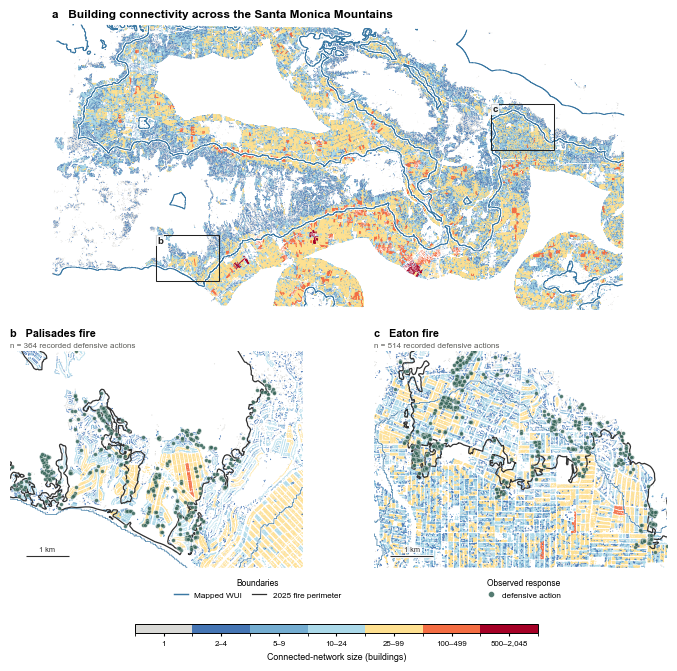

In [5]:
# Fire-region detail: use the full-county CTop2 graph with alpha=.75 and crop only for display.

DEFENSE_COLOR = "#366458FF"
DEFENSE_EDGE = "#FFFFFF"

FIRE_TOP2_ALPHA = 0.75
FIRE_TOP2_MAP_CACHE = DERIVED / 'county_sen_top2_alpha075_map_source.parquet'
if regional_cache_matches(
    FIRE_TOP2_MAP_CACHE, 'cumulative_top_2', F_IJ_THRESHOLD,
    n_neighbors=2, edge_floor_fraction=FIRE_TOP2_ALPHA,
):
    fire_regional_top2 = load_county_regional_sen_cache(
        PACKAGE_ROOT, FIRE_TOP2_MAP_CACHE, wui_path=WUI_PATH,
    )
    print(f'loaded cached alpha=.75 CTop2 assignments: {FIRE_TOP2_MAP_CACHE}')
else:
    fire_regional_top2 = build_county_regional_sen(
        PACKAGE_ROOT, OPENVIEW_3D_RUN, F_IJ_THRESHOLD, BUILDING_CACHE,
        wui_path=WUI_PATH, n_neighbors=2,
        edge_floor_fraction=FIRE_TOP2_ALPHA,
    )
    save_county_regional_sen_cache(fire_regional_top2, FIRE_TOP2_MAP_CACHE)
    print(f'cached alpha=.75 CTop2 assignments: {FIRE_TOP2_MAP_CACHE}')

FIRE_VIEWPORTS = {
    'PALISADES': ((355460, 362340), (3766200, 3771300)),
    'EATON': ((392360, 399240), (3780650, 3785750)),
}
FIRE_CMAPS = {
    'EATON': PUBLICATION_CMAP, 'PALISADES': PUBLICATION_CMAP,
}
# DEFENSE_COLOR = '#D81B60'
dins = pd.read_parquet(
    PACKAGE_ROOT / 'data' / 'enrichment' / 'dins.parquet',
    columns=['BLD_ID', 'is_defended'],
)
defended_ids = set(
    dins.loc[dins.is_defended.eq(True), 'BLD_ID'].astype(str)
)
fire_perimeters = gpd.read_parquet(
    PACKAGE_ROOT / 'data' / 'nx' / 'fire_perims.parquet'
)

buildings = fire_regional_top2['buildings']
fire_views = {}
for fire, (xlim, ylim) in FIRE_VIEWPORTS.items():
    xmin, xmax = xlim
    ymin, ymax = ylim
    candidates = buildings.cx[xmin:xmax, ymin:ymax].copy()
    points = candidates.geometry.centroid
    inside = (
        points.x.between(xmin, xmax) & points.y.between(ymin, ymax)
    )
    fire_views[fire] = (candidates.loc[inside].copy(), points.loc[inside])
shared_scale_min = max(
    1, min(int(subset.component_size.min()) for subset, _ in fire_views.values())
)
shared_scale_max = max(
    shared_scale_min + 1,
    max(int(subset.component_size.max()) for subset, _ in fire_views.values()),
)
shared_norm = LogNorm(vmin=shared_scale_min, vmax=shared_scale_max)
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.8))
fire_region_summary = []

for panel, (ax, (fire, (xlim, ylim))) in enumerate(
    zip(axes, FIRE_VIEWPORTS.items())
):
    xmin, xmax = xlim
    ymin, ymax = ylim
    subset, points = fire_views[fire]
    ax.scatter(
        points.x, points.y, c=subset.component_size,
        cmap=FIRE_CMAPS[fire], norm=shared_norm,
        s=.75, linewidths=0, alpha=.90, rasterized=True, zorder=2,
    )

    fire_buildings = gpd.read_parquet(
        PACKAGE_ROOT / 'data' / 'nx' / f'{fire}_buildings.parquet',
        columns=['BLD_ID', 'geometry'],
    ).to_crs(buildings.crs)
    fire_buildings['BLD_ID'] = fire_buildings.BLD_ID.astype(str)
    defended = fire_buildings.loc[
        fire_buildings.BLD_ID.isin(defended_ids)
    ].drop_duplicates('BLD_ID')
    defended_points = defended.geometry.representative_point()
    visible_defense = defended_points.loc[
        defended_points.x.between(xmin, xmax)
        & defended_points.y.between(ymin, ymax)
    ]
    ax.scatter(
        visible_defense.x, visible_defense.y, s=7.5, marker='o',
        facecolors=DEFENSE_COLOR, edgecolors='white', linewidths=.25,
        alpha=.85,
        rasterized=True, zorder=6,
    )

    perimeter = fire_perimeters.loc[
        fire_perimeters.FIRE_NAME.eq(fire)
    ].to_crs(buildings.crs)
    perimeter.boundary.plot(
        ax=ax, color='#303030', linewidth=.9, zorder=7,
    )
    ax.set(xlim=xlim, ylim=ylim)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(
        f'{chr(97 + panel)}  {fire.title()} — CTop2 SENs (α=.75)\n'
        f'{len(subset):,} buildings · {subset.component_id.nunique():,} '
        f'full-graph SENs · {len(visible_defense):,} defended structures',
        loc='left', fontsize=8.1, fontweight='bold', pad=4,
    )
    fire_region_summary.append({
        'fire': fire,
        'edge_floor_alpha': FIRE_TOP2_ALPHA,
        'buildings_in_view': len(subset),
        'full_graph_SENs_in_view': subset.component_id.nunique(),
        'shared_color_scale_vmin': shared_scale_min,
        'shared_color_scale_vmax': shared_scale_max,
        'documented_defense_structures_in_view': len(visible_defense),
        'documented_defense_structures_firewide': len(defended),
    })

fig.legend(handles=[
    Line2D([], [], marker='o', ls='', markerfacecolor='none',
           markeredgecolor=DEFENSE_COLOR, markeredgewidth=.9, markersize=5,
           label='documented defensive action'),
    Line2D([], [], color=INK, lw=.85, label='2025 fire perimeter'),
], loc='lower center', bbox_to_anchor=(.5, .105), ncol=2,
   frameon=False, fontsize=6.5)
tick_exp = np.arange(
    int(np.ceil(np.log2(shared_scale_min))),
    int(np.floor(np.log2(shared_scale_max))) + 1, 2,
)
ticks = sorted(set([shared_scale_min, *(2 ** tick_exp), shared_scale_max]))
cbar_ax = fig.add_axes([.22, .055, .56, .018])
cbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=shared_norm, cmap=FIRE_CMAPS['EATON']),
    cax=cbar_ax, orientation='horizontal',
)
cbar.set_ticks(ticks)
cbar.set_ticklabels([f'{value:,}' for value in ticks])
cbar.set_label(
    'Buildings in full-county CTop2 SEN (α=.75; displayed panels only)',
    fontsize=6.5,
)
cbar.ax.tick_params(labelsize=5.8, length=2)
fig.subplots_adjust(left=.015, right=.985, top=.91, bottom=.17, wspace=.035)

fire_region_summary = pd.DataFrame(fire_region_summary)
for summary_name in (
    'fire_region_top2_defense_summary.csv',
    'fire_region_ctop2_alpha075_defense_summary.csv',
):
    fire_region_summary.to_csv(RESULTS / summary_name, index=False)
stems = [
    FIGURES / 'fig5_fire_regions_clusters_defense_openview3d_top2',
    FIGURES / 'fig5_fire_regions_clusters_defense_openview3d_ctop2_alpha075',
]
for stem in stems:
    fig.savefig(
        stem.with_suffix('.pdf'), bbox_inches='tight', facecolor='white',
    )
    fig.savefig(
        stem.with_suffix('.png'), dpi=600, bbox_inches='tight',
        facecolor='white',
    )
    print('saved', stem.with_suffix('.png'))
plt.close(fig)
display(fire_region_summary)

# Publication figure: regional context above matched fire-detail panels.
overview_window = gpd.GeoSeries(
    [box(*WINDOW_BOUNDS_LON_LAT)], crs='EPSG:4326',
).to_crs(buildings.crs)
overview_geometry = overview_window.iloc[0]
oxmin, oymin, oxmax, oymax = overview_window.total_bounds
# Rebuild the overview subset here so this publication figure does not
# depend on a separate exploratory plotting cell having been executed.
overview_candidates = buildings.cx[oxmin:oxmax, oymin:oymax].copy()
overview_candidate_points = overview_candidates.geometry.centroid
inside_overview = overview_candidate_points.intersects(overview_geometry)
mountains_top2 = overview_candidates.loc[inside_overview].copy()
overview_points = overview_candidate_points.loc[inside_overview]
mapped_wui = fire_regional_top2['wui'].to_crs(buildings.crs)
full_mapped_wui_boundary = mapped_wui.geometry.union_all().boundary
mapped_wui_perimeter = gpd.GeoSeries(
    [full_mapped_wui_boundary.intersection(overview_geometry)],
    crs=buildings.crs,
)
publication_norm = SEN_SIZE_NORM
publication_cmap = SEN_SIZE_CMAP

fig_publication = plt.figure(figsize=(7.2, 6.55))
grid = fig_publication.add_gridspec(
    2, 2, height_ratios=(1.08, .82), hspace=.16, wspace=.09,
)
overview_ax = fig_publication.add_subplot(grid[0, :])
overview_ax.scatter(
    overview_points.x, overview_points.y,
    c=mountains_top2.component_size, cmap=publication_cmap,
    norm=publication_norm,
    s=.20, linewidths=0, alpha=.90, rasterized=True, zorder=2,
)
mapped_wui_perimeter.plot(
    ax=overview_ax, color='white', linewidth=1.8, zorder=5,
)
mapped_wui_perimeter.plot(
    ax=overview_ax, color=WUI_PERIMETER_COLOR, linewidth=.7, zorder=6,
)
for locator_label, (fire, (xlim, ylim)) in zip(
    ('b', 'c'), FIRE_VIEWPORTS.items(),
):
    xmin, xmax = xlim
    ymin, ymax = ylim
    overview_ax.add_patch(Rectangle(
        (xmin, ymin), xmax - xmin, ymax - ymin, fill=False,
        edgecolor='#202020', linewidth=.75, zorder=8,
    ))
    overview_ax.text(
        xmin + 110, ymax - 110, locator_label, ha='left', va='top',
        fontsize=7, fontweight='bold', color='#202020', zorder=9,
        bbox=dict(facecolor='white', edgecolor='none', alpha=.82, pad=.8),
    )
overview_ax.set(xlim=(oxmin, oxmax), ylim=(oymin, oymax))
overview_ax.set_aspect('equal')
overview_ax.set_xticks([]); overview_ax.set_yticks([])
for spine in overview_ax.spines.values():
    spine.set_visible(False)
overview_ax.set_title(
    'a   Building connectivity across the Santa Monica Mountains',
    loc='left',
    fontsize=8.5, fontweight='bold', pad=5,
)

detail_axes = [
    fig_publication.add_subplot(grid[1, 0]),
    fig_publication.add_subplot(grid[1, 1]),
]
for panel_label, ax, (fire, (xlim, ylim)) in zip(
    ('b', 'c'), detail_axes, FIRE_VIEWPORTS.items(),
):
    xmin, xmax = xlim
    ymin, ymax = ylim
    subset, points = fire_views[fire]
    ax.scatter(
        points.x, points.y, c=subset.component_size,
        cmap=publication_cmap,
        norm=publication_norm, s=.62, linewidths=0, alpha=.91,
        rasterized=True, zorder=2,
    )
    fire_buildings = gpd.read_parquet(
        PACKAGE_ROOT / 'data' / 'nx' / f'{fire}_buildings.parquet',
        columns=['BLD_ID', 'geometry'],
    ).to_crs(buildings.crs)
    fire_buildings['BLD_ID'] = fire_buildings.BLD_ID.astype(str)
    defended = fire_buildings.loc[
        fire_buildings.BLD_ID.isin(defended_ids)
    ].drop_duplicates('BLD_ID')
    defended_points = defended.geometry.representative_point()
    visible_defense = defended_points.loc[
        defended_points.x.between(xmin, xmax)
        & defended_points.y.between(ymin, ymax)
    ]
    detail_wui = gpd.GeoSeries(
        [full_mapped_wui_boundary.intersection(
            box(xmin, ymin, xmax, ymax)
        )], crs=buildings.crs,
    )
    detail_wui.plot(ax=ax, color='white', linewidth=1.25, zorder=3)
    detail_wui.plot(
        ax=ax, color=WUI_PERIMETER_COLOR, linewidth=.5, zorder=4,
    )
    perimeter = fire_perimeters.loc[
        fire_perimeters.FIRE_NAME.eq(fire)
    ].to_crs(buildings.crs)
    perimeter.boundary.plot(
        ax=ax, color='#303030', linewidth=.9, zorder=5,
    )
    ax.scatter(
        visible_defense.x, visible_defense.y, s=7.5, marker='o',
        facecolors=DEFENSE_COLOR, edgecolors='white', linewidths=.25,
        alpha=.85, rasterized=True, zorder=6,
    )
    ax.set(xlim=xlim, ylim=ylim)
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.text(
        0, 1.055, f'{panel_label}   {fire.title()} fire',
        transform=ax.transAxes, ha='left', va='bottom',
        fontsize=7.8, fontweight='bold',
    )
    ax.text(
        0, 1.012, f'n = {len(visible_defense):,} recorded defensive actions',
        transform=ax.transAxes, ha='left', va='bottom',
        fontsize=5.8, color='#5F5F5B',
    )
    scale_x = xmin + .055 * (xmax - xmin)
    scale_y = ymin + .055 * (ymax - ymin)
    ax.plot(
        [scale_x, scale_x + 1000], [scale_y, scale_y],
        color='white', linewidth=2.2, solid_capstyle='butt', zorder=8,
    )
    ax.plot(
        [scale_x, scale_x + 1000], [scale_y, scale_y],
        color='#303030', linewidth=.8, solid_capstyle='butt', zorder=9,
    )
    ax.text(
        scale_x + 500, scale_y + .018 * (ymax - ymin), '1 km',
        ha='center', va='bottom', fontsize=5.3, color='#303030',
        zorder=9,
        bbox=dict(facecolor='white', edgecolor='none', alpha=.72, pad=.4),
    )



boundary_legend = fig_publication.legend(handles=[
    Line2D([], [], color=WUI_PERIMETER_COLOR, lw=1.05,
           label='Mapped WUI'),
    Line2D([], [], color='#303030', lw=.9, label='2025 fire perimeter'),
], title='Boundaries', loc='lower center', bbox_to_anchor=(.39, .078),
   ncol=2, frameon=False, fontsize=5.9, title_fontsize=6.1,
   columnspacing=1.25, handlelength=1.7)
response_legend = fig_publication.legend(handles=[
    Line2D([], [], marker='o', ls='', markerfacecolor=DEFENSE_COLOR,
           markeredgecolor=DEFENSE_EDGE, markeredgewidth=.25, markersize=4.2,
           alpha=.85, label='defensive action'),
], title='Observed response', loc='lower center',
   bbox_to_anchor=(.76, .078), frameon=False, fontsize=5.9,
   title_fontsize=6.1, handlelength=1.2)
publication_cbar_ax = fig_publication.add_axes([.22, .036, .56, .014])
publication_cbar = fig_publication.colorbar(
    plt.cm.ScalarMappable(
        norm=publication_norm, cmap=publication_cmap,
    ),
    cax=publication_cbar_ax, orientation='horizontal',
    boundaries=SEN_SIZE_BOUNDS, ticks=SEN_SIZE_TICKS, spacing='uniform',
)
publication_cbar.set_ticklabels(SEN_SIZE_TICKLABELS)
publication_cbar.set_label(
    'Connected-network size (buildings)', fontsize=6.4,
)
publication_cbar.ax.tick_params(labelsize=5.7, length=2)
fig_publication.subplots_adjust(
    left=.018, right=.988, top=.965, bottom=.135,
)
publication_stem = (
    FIGURES
    / 'fig5_santa_monica_mountains_fire_details_openview3d_ctop2_alpha075'
)
fig_publication.savefig(
    publication_stem.with_suffix('.pdf'), bbox_inches='tight',
    facecolor='white',
)
fig_publication.savefig(
    publication_stem.with_suffix('.png'), dpi=600, bbox_inches='tight',
    facecolor='white',
)
print('saved', publication_stem.with_suffix('.png'))
plt.show()


## Reference: distance-only SENs (footprints within 30 ft)

A geometry-only benchmark for the coupling-based networks. Every pair of buildings whose footprints come within 30 ft (9.1 m), edge to edge, is linked, with no view factor, threshold or fragility involved, and SENs are the connected components. The buildings, WUI classes and screen-edge flags are those of the county graph above (solar structures excluded). The cell below builds the assignments and picks one focal building per quartile of distance-SEN size (the median size of each building-weighted quartile over mapped-WUI buildings, wholly inside the Santa Monica Mountains window); the comparisons that follow draw those buildings under each rule.

In [6]:
# Distance-only SENs: every footprint pair within 30 ft linked.
import importlib

import shapely

import src.analysis.sen as sen_analysis
import src.viz.sen_examples as sen_examples
from src.figure_paths import save_figure

importlib.reload(sen_analysis)
importlib.reload(sen_examples)

DISTANCE_FT = 30.0
DISTANCE_M = DISTANCE_FT * 0.3048
DISTANCE_CACHE = DERIVED / 'county_sen_distance30ft_assignments.parquet'

distance_buildings = regional_top2['buildings'][
    ['building_id', 'geometry', 'wui_class', 'near_screen_edge']].reset_index(drop=True)
if DISTANCE_CACHE.exists():
    cached = pd.read_parquet(DISTANCE_CACHE)
    assert cached.building_id.equals(distance_buildings.building_id)
    distance_buildings[['component_id', 'component_size']] = cached[['component_id', 'component_size']].to_numpy()
else:
    labels, sizes, _ = sen_analysis.distance_components(
        distance_buildings.geometry.to_numpy(), DISTANCE_M)
    distance_buildings['component_id'], distance_buildings['component_size'] = labels, sizes
    distance_buildings[['building_id', 'component_id', 'component_size']].to_parquet(DISTANCE_CACHE, index=False)
# A component is censored if any member sits near the screen edge.
distance_buildings['near_screen_edge'] = (
    distance_buildings.groupby('component_id').near_screen_edge.transform('max'))
print(f'{DISTANCE_FT:g} ft links: {distance_buildings.component_id.nunique():,} SENs; '
      f'largest {distance_buildings.component_size.max():,}')

# Focal buildings, one per quartile. Score F = 30 ft / gap, so a link is F >= 1.
geometries = distance_buildings.geometry.to_numpy()
building_index = pd.Series(np.arange(len(distance_buildings)), index=distance_buildings.building_id.to_numpy())
geometry_tree = shapely.STRtree(geometries)
NEIGHBOR_RADIUS_M = 2.5 * DISTANCE_M  # reaches the 0.4-threshold near-miss neighbor


def distance_edges(ids):
    rows = building_index.reindex(list(ids)).to_numpy()
    member, other = geometry_tree.query(geometries[rows], predicate='dwithin', distance=NEIGHBOR_RADIUS_M)
    a = distance_buildings.building_id.to_numpy()[rows[member]]
    b = distance_buildings.building_id.to_numpy()[other]
    keep = a != b
    gap = shapely.distance(geometries[rows[member]][keep], geometries[other][keep])
    return pd.DataFrame({
        'building_i': np.minimum(a[keep], b[keep]), 'building_j': np.maximum(a[keep], b[keep]),
        'F_ij': DISTANCE_M / np.maximum(gap, .01),
    }).drop_duplicates(['building_i', 'building_j'])


distance_cuts, distance_examples = sen_examples.quartile_examples(
    distance_buildings, None, 1.0, 'distance', WINDOW_BOUNDS_LON_LAT, edge_fn=distance_edges)
print('focal buildings:', ', '.join(f'{e.label} {e.focal} (SEN {e.size})' for e in distance_examples))

30 ft links: 195,335 SENs; largest 482
focal buildings: Q1 1104643 (SEN 2), Q2 2056233 (SEN 11), Q3 1643623 (SEN 34), Q4 2025634 (SEN 70)


### Same focal buildings: distance-only versus 3D EEAT

Each column takes the focal building of one distance-only example above and draws the SEN that contains it under each rule: footprints within 30 ft (top) and 3D OpenView EEAT at the P50 threshold (bottom). Both rows of a column share one map extent, so membership and links can be compared building for building. The focal building's dashed lines show its two nearest neighbors (top, gaps in feet) or its two strongest couplings (bottom, {ij}$).

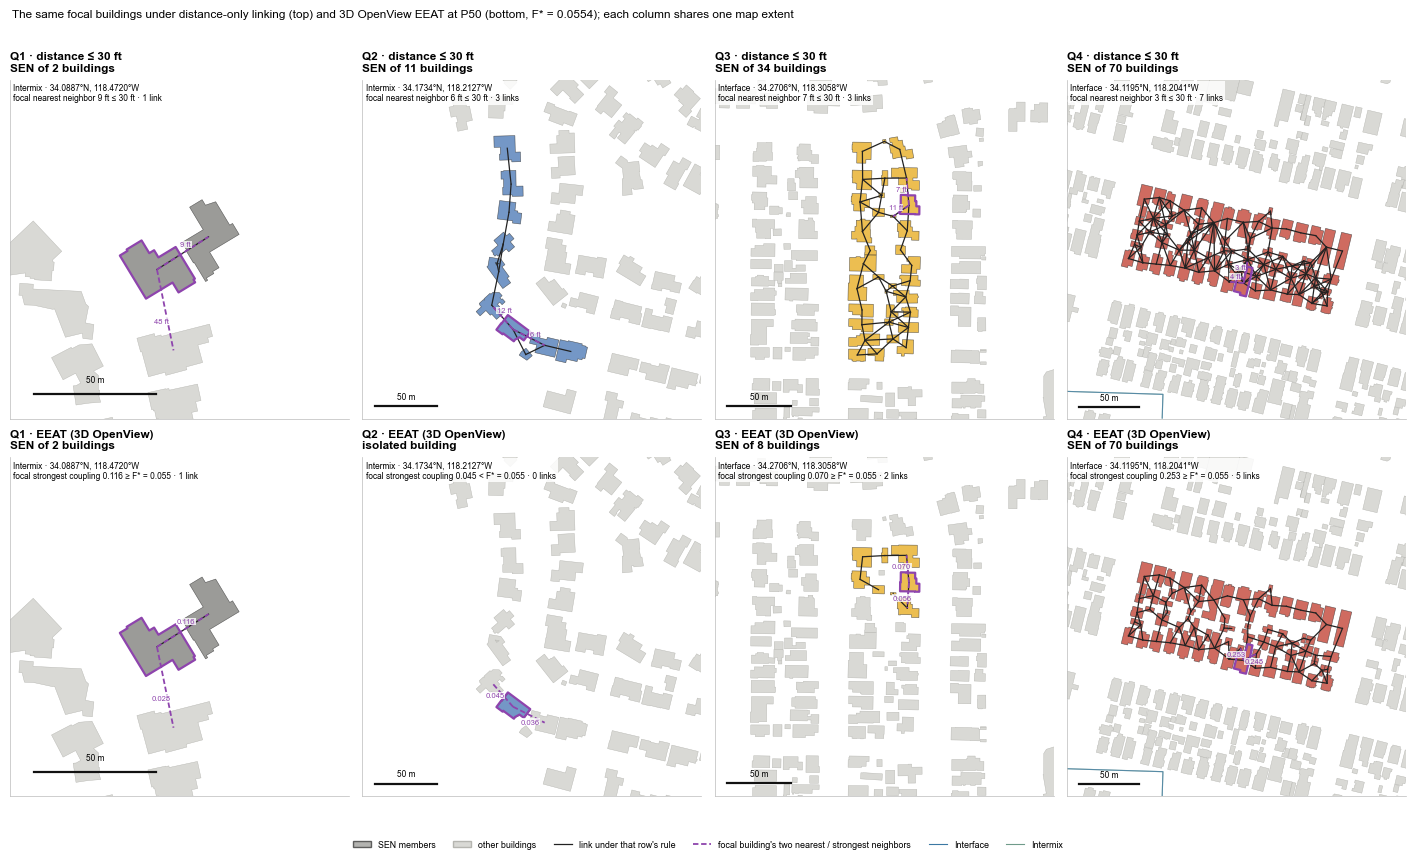

,quartile,focal_building,distance SEN size,distance links,EEAT SEN size,EEAT links,members in both,focal nearest ft,focal strongest F (3D),focal EEAT links
0,Q1,1104643,2,1,2,1,2,9.3,0.1157,1
1,Q2,2056233,11,12,1,0,1,5.6,0.0452,0
2,Q3,1643623,34,57,8,7,8,7.3,0.0698,2
3,Q4,2025634,70,189,70,114,70,2.9,0.2533,5


In [7]:
# The distance-only examples' focal buildings, under 3D EEAT at P50.
importlib.reload(sen_examples)
eeat_buildings = regional_eeat['buildings']
eeat_examples = [
    sen_examples.example_for_focal(
        eeat_buildings, example.focal, F_IJ_THRESHOLD, 'eeat', run_dir=OPENVIEW_3D_RUN,
        label=example.label, size_range=example.size_range, color=example.color)
    for example in distance_examples
]
fig_focal_compare = sen_examples.plot_focal_comparison(
    [
        dict(name=f'distance ≤ {DISTANCE_FT:g} ft', examples=distance_examples,
             buildings=distance_buildings, threshold=1.0, method='distance'),
        dict(name='EEAT (3D OpenView)', examples=eeat_examples,
             buildings=eeat_buildings, threshold=F_IJ_THRESHOLD, method='eeat'),
    ],
    regional_top2['wui'].to_crs(distance_buildings.crs), distance_ft=DISTANCE_FT,
    title=('The same focal buildings under distance-only linking (top) and 3D OpenView EEAT '
           f'at P50 (bottom, F* = {F_IJ_THRESHOLD:.4f}); each column shares one map extent'),
)
save_figure(fig_focal_compare, 'sen_examples_distance30ft_vs_eeat_same_focal', 'exploratory', dpi=300)
display(fig_focal_compare)
plt.close(fig_focal_compare)
focal_comparison = pd.DataFrame([{
    'quartile': d.label, 'focal_building': d.focal,
    'distance SEN size': d.size, 'distance links': len(d.links),
    'EEAT SEN size': e.size, 'EEAT links': len(e.links),
    'members in both': len(set(d.members.building_id) & set(e.members.building_id)),
    'focal nearest ft': round(DISTANCE_FT / d.focal_score, 1),
    'focal strongest F (3D)': round(e.focal_score, 4), 'focal EEAT links': e.focal_degree,
} for d, e in zip(distance_examples, eeat_examples)])
focal_comparison.to_csv(RESULTS / 'sen_examples_distance30ft_vs_eeat_same_focal.csv', index=False)
display(focal_comparison)

### Fire areas: matched focal buildings under distance, cumulative Top-2, and EEAT

Focal buildings are drawn inside the Eaton and Palisades perimeters, one at the median of each quartile of distance-SEN size among buildings inside the perimeters, with each distance SEN wholly inside a perimeter. The main comparison is restricted to three rows: footprints within 30 ft, 2D OpenView cumulative Top-2, and 3D OpenView cumulative Top-2. A separate companion figure compares 2D and 3D EEAT for the same focal buildings. The 2D rules use the locally inverted 3D P50 midpoint, $F^*_{2D}=0.1653$, rather than the independently fitted direct 2D midpoint. The 3D rules retain $F^*_{3D}=0.0554$; cumulative Top-2 uses $\alpha=0.75$ in both dimensions. The 2D graph uses LARIAC footprints with sides split into pieces of at most 2 m and is restricted to the same buildings as the other rules (solar structures excluded). Hatching marks DINS-destroyed buildings.


2D graph threshold: local inverse of 3D P50 = 0.165264; direct 2D P50 retained for reference = 0.279835


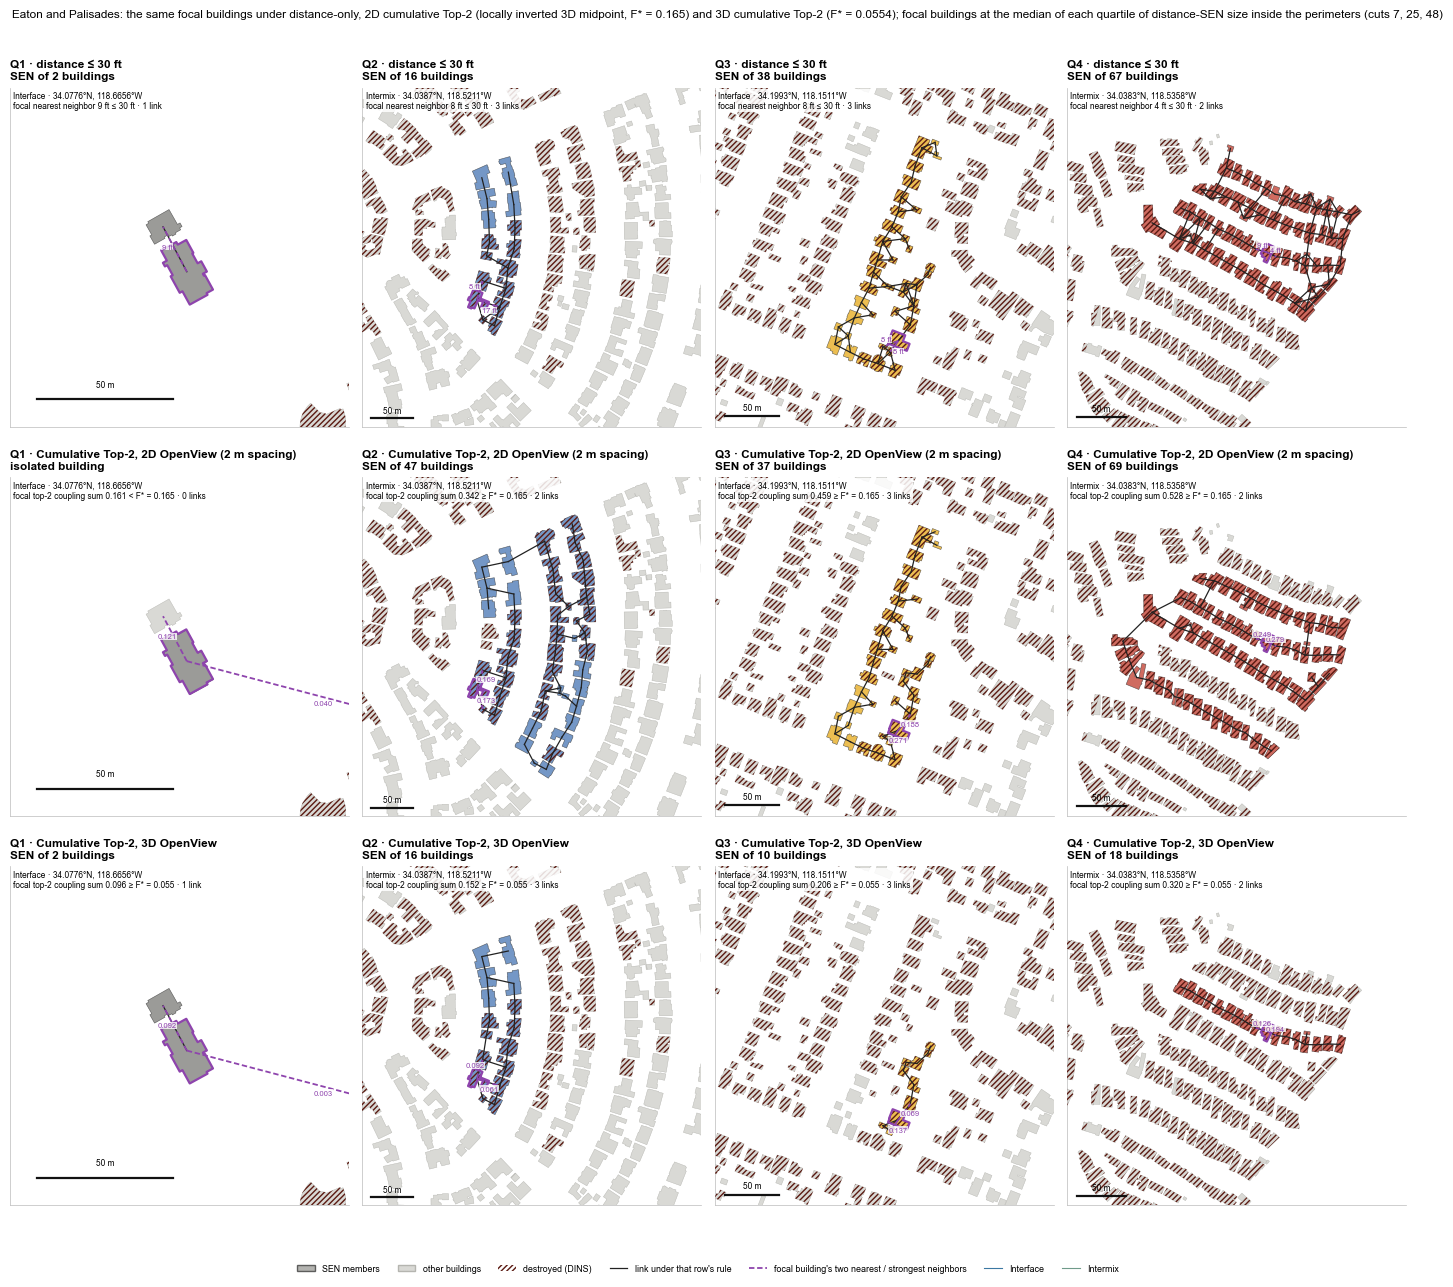

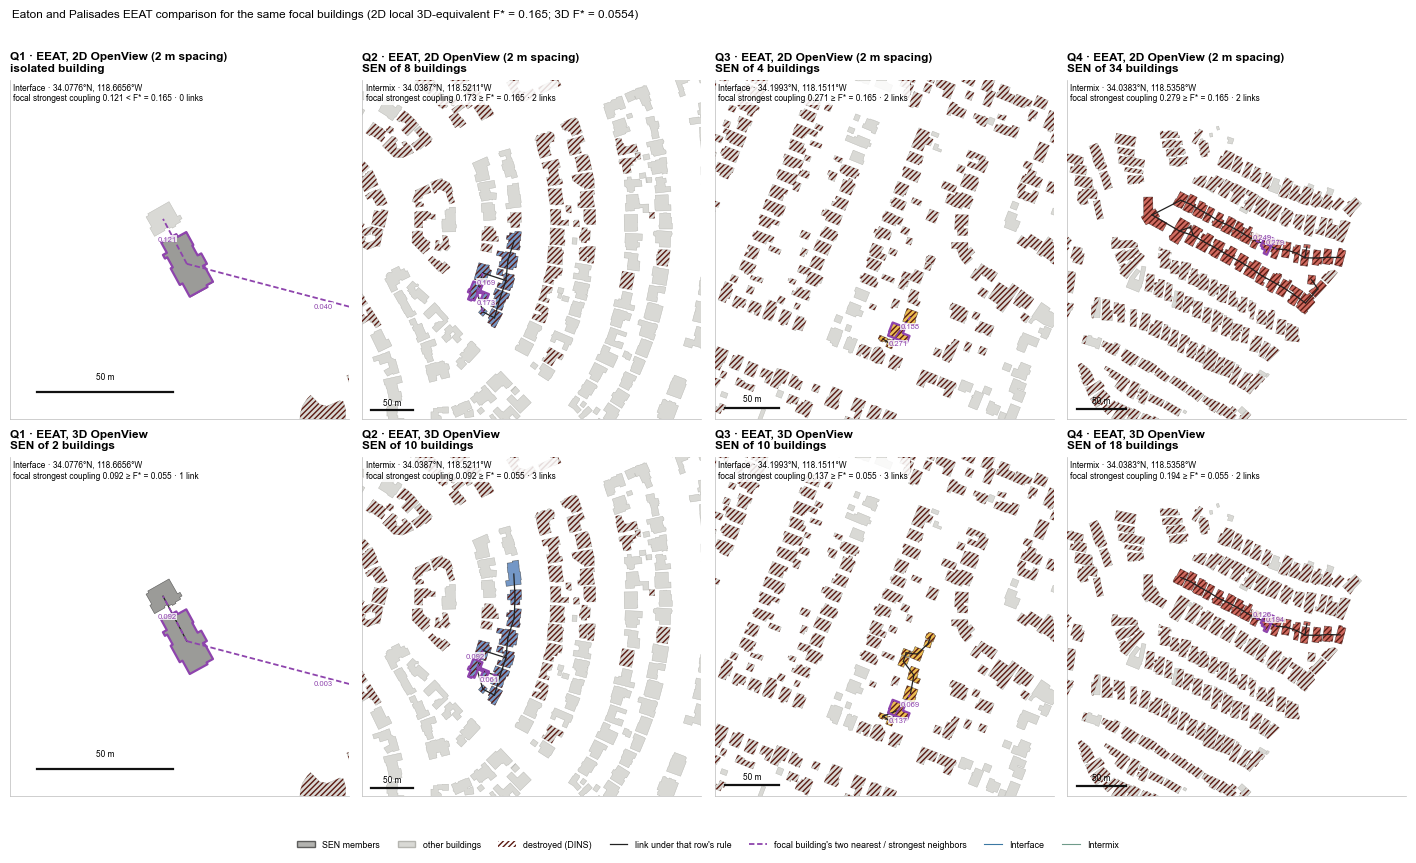

,quartile,focal_building,focal destroyed,distance size,2D EEAT size,2D Top-2 size,3D EEAT size,3D Top-2 size,2D ∩ distance,3D ∩ distance,3D ∩ 2D,3D Top-2 ∩ 3D EEAT,destroyed share (distance / 2D EEAT / 2D Top-2 / 3D EEAT / 3D Top-2)
0,Q1,738887,False,2,1,1,2,2,1,2,1,2,0.00 / 0.00 / 0.00 / 0.00 / 0.00
1,Q2,821273,True,16,8,47,10,16,8,10,8,10,0.69 / 1.00 / 0.62 / 0.90 / 0.69
2,Q3,2071405,True,38,4,37,10,10,4,10,4,10,0.79 / 1.00 / 0.78 / 1.00 / 1.00
3,Q4,774917,True,67,34,69,18,18,34,18,18,18,0.87 / 0.94 / 0.91 / 0.94 / 0.94


,rule,buildings,isolated %,median SEN size,P90 SEN size
0,distance ≤ 30 ft,22838,8.5,25.0,74.0
1,2D EEAT,22838,24.2,5.0,26.0
2,2D cumulative Top-2,22838,9.1,21.0,89.0
3,3D EEAT,22838,19.8,7.0,39.0
4,3D cumulative Top-2,22838,14.0,13.0,50.0


In [8]:
# Fire-area focal buildings under distance-only, 2D and 3D cumulative
# Top-2, with a separate 2D-versus-3D EEAT companion figure.
import importlib

from scipy import sparse
from scipy.sparse.csgraph import connected_components

import src.analysis.carsen as carsen_analysis

importlib.reload(carsen_analysis)
importlib.reload(sen_examples)

FIRE_2D_RUN = Path(os.environ.get(
    'OPENVIEW_FIRE_2D_SEG2M_DIR',
    '/Users/adamswietek/Documents/PostDoc/openview/results/fires_eaton_palisades_800m_bvf_2d_lariac_seg2m',
))
LEGACY_ANALYSIS = PACKAGE_ROOT.parent / 'data' / 'analysis.parquet'  # population of the original 2D fit
fire_perimeters = gpd.read_parquet(PACKAGE_ROOT / 'data' / 'nx' / 'fire_perims.parquet').to_crs(distance_buildings.crs)
fire_area = fire_perimeters[fire_perimeters.FIRE_NAME.isin(['EATON', 'PALISADES'])].geometry.union_all()

# Keep the direct 2D fit for provenance, but use the 3D P50 midpoint
# locally inverse-mapped onto the 2D scale for both 2D graph definitions.
dose_2d_path = carsen_analysis.build_fire_dose_2d(
    FIRE_2D_RUN, LEGACY_ANALYSIS, DERIVED / 'fire_building_dose_2d_seg2m.parquet')
_, fits_2d = carsen_analysis.fit_2d_fragility(dose_2d_path)
F_2D_DIRECT_P50 = float(fits_2d['POOLED']['absolute_p50'])
F_2D_STAR = 0.16526373070
print(
    f'2D graph threshold: local inverse of 3D P50 = {F_2D_STAR:.6f}; '
    f'direct 2D P50 retained for reference = {F_2D_DIRECT_P50:.6f}'
)

# 2D EEAT components on the same buildings as the other rules (solar excluded).
fire_ids = pd.read_parquet(FIRE_2D_RUN / 'building_ids.parquet', columns=['building_id']).building_id
fire_ids = fire_ids[fire_ids.isin(distance_buildings.building_id)].to_numpy()
edges_2d = pd.read_parquet(FIRE_2D_RUN / 'building_edges.parquet',
                           columns=['building_i', 'building_j', 'vf_i_to_j', 'vf_j_to_i'])
edges_2d = edges_2d[edges_2d.building_i.isin(fire_ids) & edges_2d.building_j.isin(fire_ids)].copy()
edges_2d['F_ij'] = np.maximum(edges_2d.vf_i_to_j, edges_2d.vf_j_to_i)
position = pd.Series(np.arange(len(fire_ids)), index=fire_ids)
strong = edges_2d[edges_2d.F_ij.ge(F_2D_STAR)]
_, labels_2d = connected_components(sparse.coo_matrix(
    (np.ones(len(strong)), (position[strong.building_i].to_numpy(), position[strong.building_j].to_numpy())),
    shape=(len(fire_ids),) * 2), directed=False)
buildings_2d = (distance_buildings[distance_buildings.building_id.isin(fire_ids)]
                [['building_id', 'geometry', 'wui_class']].reset_index(drop=True))
buildings_2d['component_id'] = labels_2d[position[buildings_2d.building_id].to_numpy()]
buildings_2d['component_size'] = buildings_2d.groupby('component_id').building_id.transform('size')

# 2D cumulative Top-2 (alpha .75) on the same graph and threshold.
top2_links_2d = sen_examples.method_links(
    edges_2d[['building_i', 'building_j', 'F_ij']], set(fire_ids), F_2D_STAR, 'top2',
    edge_floor_fraction=TOP2_EDGE_FLOOR_ALPHA)
top2_pairs_2d = np.array(sorted(top2_links_2d), dtype=np.int64).reshape(-1, 2)
_, labels_2d_top2 = connected_components(sparse.coo_matrix(
    (np.ones(len(top2_pairs_2d)), (position[top2_pairs_2d[:, 0]].to_numpy(),
                                   position[top2_pairs_2d[:, 1]].to_numpy())),
    shape=(len(fire_ids),) * 2), directed=False)
buildings_2d_top2 = buildings_2d[['building_id', 'geometry', 'wui_class']].copy()
buildings_2d_top2['component_id'] = labels_2d_top2[position[buildings_2d_top2.building_id].to_numpy()]
buildings_2d_top2['component_size'] = (
    buildings_2d_top2.groupby('component_id').building_id.transform('size'))


def edges_2d_touching(ids):
    touching = edges_2d.building_i.isin(ids) | edges_2d.building_j.isin(ids)
    return edges_2d.loc[touching, ['building_i', 'building_j', 'F_ij']]


# Focal buildings: one per quartile of distance-SEN size among buildings inside
# the two perimeters, each distance SEN wholly inside a perimeter.
candidates = distance_buildings.cx[slice(*fire_area.bounds[::2]), slice(*fire_area.bounds[1::2])]
inside = candidates.geometry.representative_point().within(fire_area).to_numpy()
fire_quartiles = sen_examples.size_quartiles(candidates.loc[inside, 'component_size'])
_, fire_distance_examples = sen_examples.quartile_examples(
    distance_buildings, None, 1.0, 'distance', fire_area, edge_fn=distance_edges,
    quartiles=fire_quartiles)
fire_examples_2d = [
    sen_examples.example_for_focal(
        buildings_2d, example.focal, F_2D_STAR, 'eeat', edge_fn=edges_2d_touching,
        label=example.label, size_range=example.size_range, color=example.color)
    for example in fire_distance_examples]
fire_examples_2d_top2 = [
    sen_examples.example_for_focal(
        buildings_2d_top2, example.focal, F_2D_STAR, 'top2', edge_fn=edges_2d_touching,
        label=example.label, size_range=example.size_range, color=example.color,
        edge_floor_fraction=TOP2_EDGE_FLOOR_ALPHA)
    for example in fire_distance_examples]
fire_examples_3d = [
    sen_examples.example_for_focal(
        regional_eeat['buildings'], example.focal, F_IJ_THRESHOLD, 'eeat',
        run_dir=OPENVIEW_3D_RUN, label=example.label, size_range=example.size_range,
        color=example.color)
    for example in fire_distance_examples]

fire_examples_3d_top2 = [
    sen_examples.example_for_focal(
        regional_top2['buildings'], example.focal, F_IJ_THRESHOLD, 'top2',
        run_dir=OPENVIEW_3D_RUN, label=example.label, size_range=example.size_range,
        color=example.color, edge_floor_fraction=TOP2_EDGE_FLOOR_ALPHA)
    for example in fire_distance_examples]

outcomes = pd.read_parquet(ANALYSIS_PATH, columns=['graph_id', 'is_destroyed'])
destroyed_ids = set(outcomes.loc[outcomes.is_destroyed.eq(1), 'graph_id'].astype('int64'))
# Compute extents across all five rules once, then reuse them in both
# figures so separating EEAT does not change the apparent map scale.
shared_fire_extents = sen_examples.focal_comparison_extents([
    {'examples': fire_distance_examples},
    {'examples': fire_examples_2d_top2},
    {'examples': fire_examples_3d_top2},
    {'examples': fire_examples_2d},
    {'examples': fire_examples_3d},
])

fig_fire_top2 = sen_examples.plot_focal_comparison(
    [
        dict(name=f'distance ≤ {DISTANCE_FT:g} ft', examples=fire_distance_examples,
             buildings=distance_buildings, threshold=1.0, method='distance'),
        dict(name='Cumulative Top-2, 2D OpenView (2 m spacing)',
             examples=fire_examples_2d_top2, buildings=buildings_2d_top2,
             threshold=F_2D_STAR, method='top2'),
        dict(name='Cumulative Top-2, 3D OpenView', examples=fire_examples_3d_top2,
             buildings=regional_top2['buildings'], threshold=F_IJ_THRESHOLD,
             method='top2'),
    ],
    regional_top2['wui'].to_crs(distance_buildings.crs), distance_ft=DISTANCE_FT,
    destroyed=destroyed_ids, extents=shared_fire_extents,
    title=('Eaton and Palisades: the same focal buildings under distance-only, '
           f'2D cumulative Top-2 (locally inverted 3D midpoint, F* = {F_2D_STAR:.3f}) '
           f'and 3D cumulative Top-2 (F* = {F_IJ_THRESHOLD:.4f}); focal buildings '
           f'at the median of each quartile of distance-SEN size inside the '
           f'perimeters (cuts {", ".join(f"{c:g}" for c in fire_quartiles[0])})'),
)
save_figure(
    fig_fire_top2, 'sen_examples_fire_distance_2d_3d_same_focal',
    'exploratory', dpi=300,
)
display(fig_fire_top2)
plt.close(fig_fire_top2)

fig_fire_eeat = sen_examples.plot_focal_comparison(
    [
        dict(name='EEAT, 2D OpenView (2 m spacing)', examples=fire_examples_2d,
             buildings=buildings_2d, threshold=F_2D_STAR, method='eeat'),
        dict(name='EEAT, 3D OpenView', examples=fire_examples_3d,
             buildings=regional_eeat['buildings'], threshold=F_IJ_THRESHOLD,
             method='eeat'),
    ],
    regional_top2['wui'].to_crs(distance_buildings.crs), distance_ft=DISTANCE_FT,
    destroyed=destroyed_ids, extents=shared_fire_extents,
    title=('Eaton and Palisades EEAT comparison for the same focal buildings '
           f'(2D local 3D-equivalent F* = {F_2D_STAR:.3f}; '
           f'3D F* = {F_IJ_THRESHOLD:.4f})'),
)
save_figure(
    fig_fire_eeat, 'sen_examples_fire_eeat_2d_3d_same_focal',
    'exploratory', dpi=300,
)
display(fig_fire_eeat)
plt.close(fig_fire_eeat)


def _destroyed_share(example):
    return np.mean([b in destroyed_ids for b in example.members.building_id])


fire_rule_table = pd.DataFrame([{
    'quartile': d.label, 'focal_building': d.focal, 'focal destroyed': d.focal in destroyed_ids,
    'distance size': d.size, '2D EEAT size': t.size, '2D Top-2 size': c.size,
    '3D EEAT size': h.size, '3D Top-2 size': h2.size,
    '2D ∩ distance': len(set(t.members.building_id) & set(d.members.building_id)),
    '3D ∩ distance': len(set(h.members.building_id) & set(d.members.building_id)),
    '3D ∩ 2D': len(set(h.members.building_id) & set(t.members.building_id)),
    '3D Top-2 ∩ 3D EEAT': len(set(h2.members.building_id) & set(h.members.building_id)),
    'destroyed share (distance / 2D EEAT / 2D Top-2 / 3D EEAT / 3D Top-2)': (
        f'{_destroyed_share(d):.2f} / {_destroyed_share(t):.2f} / '
        f'{_destroyed_share(c):.2f} / {_destroyed_share(h):.2f} / {_destroyed_share(h2):.2f}'),
} for d, t, c, h, h2 in zip(fire_distance_examples, fire_examples_2d, fire_examples_2d_top2,
                            fire_examples_3d, fire_examples_3d_top2)])
fire_rule_table.to_csv(RESULTS / 'sen_examples_fire_distance_2d_3d_same_focal.csv', index=False)
display(fire_rule_table)

# How each rule partitions the buildings inside the two perimeters.
inside_ids = candidates.loc[inside, 'building_id']
rule_sizes = {
    f'distance ≤ {DISTANCE_FT:g} ft': distance_buildings.set_index('building_id').component_size,
    '2D EEAT': buildings_2d.set_index('building_id').component_size,
    '2D cumulative Top-2': buildings_2d_top2.set_index('building_id').component_size,
    '3D EEAT': regional_eeat['buildings'].set_index('building_id').component_size,
    '3D cumulative Top-2': regional_top2['buildings'].set_index('building_id').component_size,
}
fire_rule_summary = pd.DataFrame([{
    'rule': rule, 'buildings': int(sizes.reindex(inside_ids).notna().sum()),
    'isolated %': 100 * sizes.reindex(inside_ids).eq(1).mean(),
    'median SEN size': sizes.reindex(inside_ids).median(),
    'P90 SEN size': sizes.reindex(inside_ids).quantile(.9),
} for rule, sizes in rule_sizes.items()])
fire_rule_summary.to_csv(RESULTS / 'sen_fire_area_size_by_rule.csv', index=False)
display(fire_rule_summary.round(1))

### Supplementary figure: Santa Monica Mountains and fire details with distance-only SENs

The publication figure above (overview of the Santa Monica Mountains window with Palisades and Eaton details), redrawn with SENs from the 30 ft distance rule instead of 3D cumulative Top-2. Everything else is held fixed: the same buildings, windows, size classes, mapped-WUI boundary, 2025 perimeters and DINS defensive actions. `plot_mountains_fire_details` reproduces the Top-2 figure pixel for pixel when given the Top-2 assignments.

saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/supplementary/fig5_santa_monica_mountains_fire_details_distance30ft.png


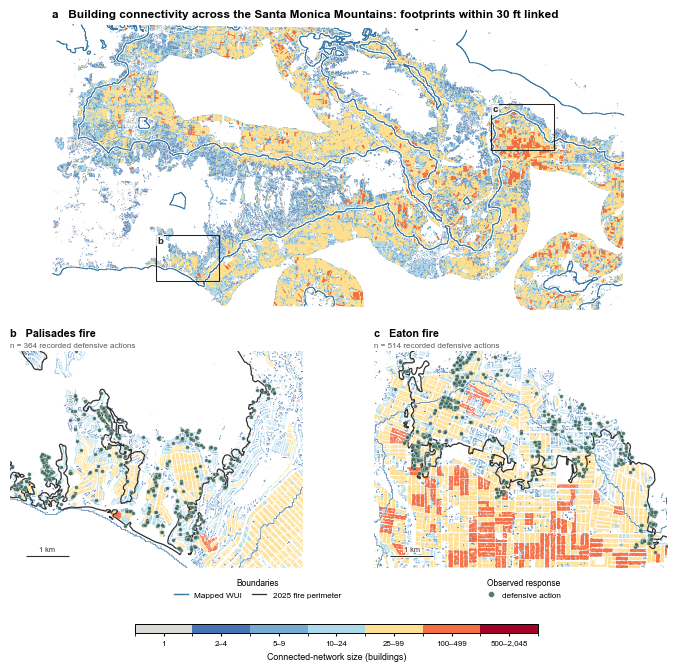

,fire,buildings_in_view,SENs_in_view,isolated_share,median_SEN_size,largest_SEN_in_view,defended_in_view,rule
0,PALISADES,16191,2751,0.085,24.0,171,364,3D cumulative Top-2 (α=.75)
1,EATON,51426,8496,0.070,16.0,131,514,3D cumulative Top-2 (α=.75)
2,PALISADES,16191,2075,0.052,30.0,183,364,distance ≤ 30 ft
3,EATON,51426,2999,0.022,71.0,301,514,distance ≤ 30 ft


In [9]:
import importlib

import src.viz.regional_sen as regional_sen_viz
from src.figure_paths import save_figure

importlib.reload(regional_sen_viz)

fig_distance_fires, distance_fire_summary = regional_sen_viz.plot_mountains_fire_details(
    distance_buildings, fire_regional_top2['wui'], fire_perimeters, defended_ids,
    PACKAGE_ROOT / 'data' / 'nx',
    viewports=FIRE_VIEWPORTS, window_lonlat=WINDOW_BOUNDS_LON_LAT,
    norm=SEN_SIZE_NORM, cmap=SEN_SIZE_CMAP, bounds=SEN_SIZE_BOUNDS,
    ticks=SEN_SIZE_TICKS, ticklabels=SEN_SIZE_TICKLABELS,
    overview_title=('a   Building connectivity across the Santa Monica Mountains: '
                    f'footprints within {DISTANCE_FT:g} ft linked'),
    wui_color=WUI_PERIMETER_COLOR, defense_color=DEFENSE_COLOR, defense_edge=DEFENSE_EDGE,
)
# Supplementary figure: the distance-only counterpart of the main-text map.
distance_fire_stem = save_figure(
    fig_distance_fires, 'fig5_santa_monica_mountains_fire_details_distance30ft', 'supplementary', dpi=600)
print('saved', distance_fire_stem.with_suffix('.png'))
display(fig_distance_fires)
plt.close(fig_distance_fires)

# The same fire windows under 3D cumulative Top-2, for comparison.
_, top2_fire_summary = regional_sen_viz.plot_mountains_fire_details(
    fire_regional_top2['buildings'], fire_regional_top2['wui'], fire_perimeters, defended_ids,
    PACKAGE_ROOT / 'data' / 'nx', viewports=FIRE_VIEWPORTS,
    window_lonlat=WINDOW_BOUNDS_LON_LAT, norm=SEN_SIZE_NORM, cmap=SEN_SIZE_CMAP,
    bounds=SEN_SIZE_BOUNDS, ticks=SEN_SIZE_TICKS, ticklabels=SEN_SIZE_TICKLABELS)
plt.close('all')
fire_window_comparison = pd.concat([
    top2_fire_summary.assign(rule='3D cumulative Top-2 (α=.75)'),
    distance_fire_summary.assign(rule=f'distance ≤ {DISTANCE_FT:g} ft'),
], ignore_index=True)
fire_window_comparison.to_csv(RESULTS / 'fire_windows_sen_size_top2_vs_distance30ft.csv', index=False)
display(fire_window_comparison.round(3))

### Supplementary figure: statewide 2D cumulative Top-2 SENs at the midpoint-average threshold

This repeats the Santa Monica Mountains overview and matched Palisades/Eaton detail windows using the statewide OSM 2D coupling graph. The cumulative Top-2 threshold is the arithmetic mean of the direct statewide 2D midpoint and the locally inverse-mapped 3D midpoint, $F^*_{2D}=(0.25557+0.16526)/2=0.21042$, with $\alpha=0.75$. Statewide OSM components are mapped to the LARIAC display footprints through the conservative one-to-one centroid crosswalk from notebook 06, preserving the fire perimeters and defensive-action overlays. LARIAC buildings without a one-to-one OSM match are drawn in neutral gray and do not receive an inferred SEN size.


saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/supplementary/fig5_santa_monica_mountains_fire_details_2d_ctop2_midpoint_average.png


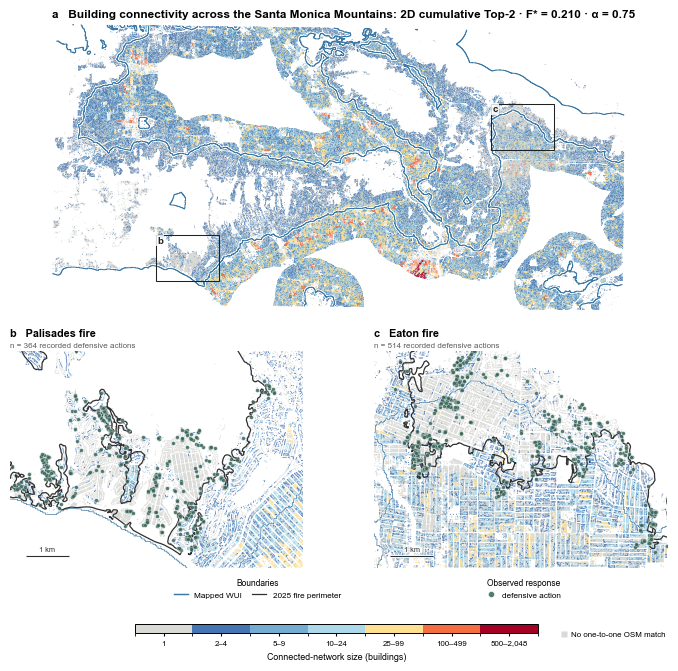

,fire,buildings_in_view,SENs_in_view,isolated_share,median_SEN_size,largest_SEN_in_view,defended_in_view,F_2d_threshold,edge_floor_alpha,matched_display_buildings,unmatched_display_buildings
0,PALISADES,16191,4499,0.170,3.0,60,364,0.21,0.75,1401943,154809
1,EATON,51426,11427,0.137,5.0,73,514,0.21,0.75,1401943,154809


In [10]:
# Statewide 2D CTop2 memberships at the midpoint-average robustness threshold,
# mapped onto LARIAC display footprints through the notebook 06 crosswalk.
import importlib

import src.viz.regional_sen as regional_sen_viz
from src.figure_paths import save_figure
from src.analysis.carsen import (
    build_statewide_components, build_statewide_ranked_incidence,
)

importlib.reload(regional_sen_viz)

STATE_2D_RUN = Path(os.environ.get(
    'OPENVIEW_CA_2D_BVF_DIR',
    '/Users/adamswietek/Documents/PostDoc/openview/results/'
    'california_wui_all_3mi_osm_2d/full_california',
))
CARSEN_DERIVED = (
    PACKAGE_ROOT / 'data' / 'derived' / 'carsen_2d_vs_3d'
    / 'california_wui_all_3mi_osm_2d'
)
STATE_COMPONENTS_2D = CARSEN_DERIVED / 'statewide_components'
RANKED_INCIDENCE_2D = (
    STATE_COMPONENTS_2D / 'california_top2_ranked_incidence.parquet'
)
AVERAGE_COMPONENTS_2D = (
    STATE_COMPONENTS_2D / 'threshold_comparison'
    / 'midpoint_average_robustness'
)
COUNTY_STATE_CROSSWALK = (
    CARSEN_DERIVED / 'county_3d_to_state_2d_building_crosswalk.parquet'
)

F_2D_DIRECT_STATEWIDE = 0.2555667290936599
F_2D_INVERTED_3D = 0.16526373070
F_2D_MIDPOINT_AVERAGE = float(np.mean([
    F_2D_DIRECT_STATEWIDE, F_2D_INVERTED_3D,
]))

ranked_2d = build_statewide_ranked_incidence(
    STATE_2D_RUN, RANKED_INCIDENCE_2D, maximum_rank=2,
)
average_2d_paths = build_statewide_components(
    STATE_2D_RUN, AVERAGE_COMPONENTS_2D, F_2D_MIDPOINT_AVERAGE,
    'top2', ranked_path=ranked_2d, n_neighbors=2,
    edge_floor_fraction=TOP2_EDGE_FLOOR_ALPHA,
)
if not COUNTY_STATE_CROSSWALK.exists():
    raise FileNotFoundError(
        'Run the county-to-state crosswalk cell in 06_carsen.ipynb first: '
        f'{COUNTY_STATE_CROSSWALK}'
    )

crosswalk_2d = pd.read_parquet(
    COUNTY_STATE_CROSSWALK,
    columns=['building_3d', 'building_2d', 'centroid_distance_m'],
)
if crosswalk_2d.building_3d.duplicated().any() or crosswalk_2d.building_2d.duplicated().any():
    raise RuntimeError('The county-to-state display crosswalk is not one-to-one')
assignments_2d_average = pd.read_parquet(
    average_2d_paths['assignments'],
    columns=['building_id', 'component_id', 'component_size'],
).rename(columns={
    'building_id': 'building_2d',
    'component_id': 'component_id_2d',
    'component_size': 'component_size_2d',
})
display_assignment_2d = crosswalk_2d.merge(
    assignments_2d_average, on='building_2d', how='left',
    validate='one_to_one',
)

base_display = fire_regional_top2['buildings'][[
    'building_id', 'geometry',
]].copy()
buildings_2d_average = base_display.merge(
    display_assignment_2d.rename(columns={'building_3d': 'building_id'}),
    on='building_id', how='left', validate='one_to_one',
)
# The plotting API expects these canonical fields. Missing crosswalk matches
# remain NaN so they are rendered with the explicit neutral missing-data color.
buildings_2d_average['component_id'] = buildings_2d_average.component_id_2d
buildings_2d_average['component_size'] = buildings_2d_average.component_size_2d

fig_2d_average_fires, summary_2d_average_fires = (
    regional_sen_viz.plot_mountains_fire_details(
        buildings_2d_average, fire_regional_top2['wui'], fire_perimeters,
        defended_ids, PACKAGE_ROOT / 'data' / 'nx',
        viewports=FIRE_VIEWPORTS, window_lonlat=WINDOW_BOUNDS_LON_LAT,
        norm=SEN_SIZE_NORM, cmap=SEN_SIZE_CMAP, bounds=SEN_SIZE_BOUNDS,
        ticks=SEN_SIZE_TICKS, ticklabels=SEN_SIZE_TICKLABELS,
        overview_title=(
            'a   Building connectivity across the Santa Monica Mountains: '
            f'2D cumulative Top-2 · F* = {F_2D_MIDPOINT_AVERAGE:.3f} · '
            f'α = {TOP2_EDGE_FLOOR_ALPHA:g}'
        ),
        wui_color=WUI_PERIMETER_COLOR, defense_color=DEFENSE_COLOR,
        defense_edge=DEFENSE_EDGE,
        missing_color='#D9D9D6', missing_label='No one-to-one OSM match',
    )
)
average_2d_fire_stem = save_figure(
    fig_2d_average_fires,
    'fig5_santa_monica_mountains_fire_details_2d_ctop2_midpoint_average',
    'supplementary', dpi=600,
)
print('saved', average_2d_fire_stem.with_suffix('.png'))
display(fig_2d_average_fires)
plt.close(fig_2d_average_fires)

summary_2d_average_fires['F_2d_threshold'] = F_2D_MIDPOINT_AVERAGE
summary_2d_average_fires['edge_floor_alpha'] = TOP2_EDGE_FLOOR_ALPHA
summary_2d_average_fires['matched_display_buildings'] = int(
    buildings_2d_average.component_size.notna().sum()
)
summary_2d_average_fires['unmatched_display_buildings'] = int(
    buildings_2d_average.component_size.isna().sum()
)
summary_2d_average_fires.to_csv(
    RESULTS / 'fire_windows_2d_ctop2_midpoint_average_summary.csv',
    index=False,
)
display(summary_2d_average_fires.round(3))


## Figure 5 — cumulative Top-2 connectivity within the mapped WUI

The figure uses the Santa Monica Mountains window, cropped to the largest rectangle inside the projected window. Components are built countywide and never rebuilt within the crop. Mapped-WUI buildings (Influence Zone, Intermix, and Interface) are colored by the number of mapped-WUI buildings in their full-county cumulative Top-2 SEN at P50, using the $\alpha=0.75$ edge floor. The 2025 Eaton and Palisades fire perimeters are retained as geographic references.

saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/main/Fig5_santa_monica_mapped_wui_connectivity_top2_alpha075_p50.png


,0
method,Cumulative Top-2 · α = 0.75 · P50
persistence_method,top2
buildings_in_view,1010284
mapped_wui_buildings_in_view,332906
largest_mapped_wui_component,410
connected_mapped_wui_share_in_view,0.856506
outside_wui_buildings_in_view,0
minimum_component_size,10
fire_perimeters_shown,2


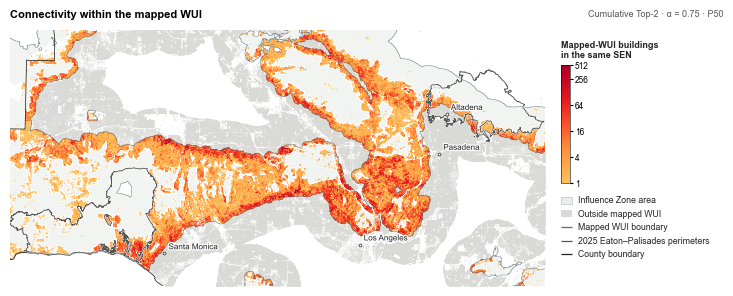

In [11]:
# Figure 5: cumulative Top-2 (alpha=.75, P50) connectivity within the mapped WUI.
import importlib

import src.viz.carsen as carsen_viz

importlib.reload(carsen_viz)

crs = regional_top2['buildings'].crs
# Building centroids for the window query (one row per graph building).
BUILDING_CENTROIDS = DERIVED / 'county_building_centroids.parquet'
centroids = regional_top2['buildings'].geometry.representative_point()
pd.DataFrame({
    'building_id': regional_top2['buildings'].building_id.to_numpy(),
    'x': centroids.x.to_numpy(), 'y': centroids.y.to_numpy(),
}).to_parquet(BUILDING_CENTROIDS, index=False)
la_county_boundary = gpd.read_parquet(
    PACKAGE_ROOT.parent / 'data' / 'reference' / 'la_county_mainland_boundary.parquet'
).to_crs(crs)
# Crop inside the projected window so the map has no empty edges.
wui_window = gpd.GeoSeries([box(*WINDOW_BOUNDS_LON_LAT)], crs='EPSG:4326').to_crs(crs)
WUI_FIGURE_BOUNDS = carsen_viz.inscribed_bounds(wui_window.iloc[0])
WUI_FIGURE_FIRE_PERIMETERS = gpd.read_parquet(PACKAGE_ROOT / 'data' / 'nx' / 'fire_perims.parquet')
WUI_FIGURE_FIRE_PERIMETERS = WUI_FIGURE_FIRE_PERIMETERS.loc[
    WUI_FIGURE_FIRE_PERIMETERS.FIRE_NAME.isin(['EATON', 'PALISADES'])
].copy()
FIGURE_5_DIR = PACKAGE_ROOT / 'figures' / 'main'
FIGURE_5_DIR.mkdir(parents=True, exist_ok=True)
WUI_FIGURE_TOP2 = FIGURE_5_DIR / 'Fig5_santa_monica_mapped_wui_connectivity_top2_alpha075_p50'
# The single-panel form reads no threshold-persistence data, so none is passed.
fig_wui_paper_top2, wui_paper_top2 = carsen_viz.plot_wui_connectivity_figure(
    TOP2_MAP_CACHE, BUILDING_CENTROIDS, None, 'top2',
    regional_top2['wui'], la_county_boundary, WUI_FIGURE_BOUNDS, WUI_FIGURE_TOP2,
    method_label=f'Cumulative Top-2 · α = {TOP2_EDGE_FLOOR_ALPHA:g} · P50',
    fire_perimeters=WUI_FIGURE_FIRE_PERIMETERS, places=COUNTY_PLACES, within_only=True,
)
wui_paper_top2.to_csv(RESULTS / 'fig5_mapped_wui_connectivity_top2_alpha075_p50_summary.csv', index=False)
print('saved', WUI_FIGURE_TOP2.with_suffix('.png'))
display(wui_paper_top2.T)

## Exploratory: destruction beyond the mapped WUI in Eaton

Assessed Eaton structures inside the fire perimeter but outside all mapped WUI classes are divided into ten intervals evenly spaced on log(1 + distance) from the nearest mapped-WUI polygon. The table compares their median countywide SEN size under the primary 3D cumulative Top-2 rule and the 30-ft distance-only benchmark, alongside the observed destruction share and, for each rule, the share of destroyed buildings whose SEN contains at least one mapped-WUI building.

In [12]:
# Eaton structures reached after the fire moved beyond the mapped WUI.
eaton_outcomes = pd.read_parquet(
    ANALYSIS_PATH, columns=['graph_id', 'fire', 'is_destroyed'],
).loc[lambda frame: frame.fire.eq('EATON')].copy()
eaton_outcomes['graph_id'] = eaton_outcomes.graph_id.astype('int64')

top2_lookup = regional_top2['buildings'][
    ['building_id', 'geometry', 'wui_class', 'component_id', 'component_size']
].rename(columns={
    'component_id': 'component_id_3d_top2',
    'component_size': 'sen_size_3d_top2',
})
top2_lookup['wui_linked_3d_top2'] = (
    top2_lookup.wui_class.ne('Outside mapped WUI')
    .groupby(top2_lookup.component_id_3d_top2).transform('any')
)
distance_lookup = distance_buildings[
    ['building_id', 'wui_class', 'component_id', 'component_size']
].rename(columns={
    'wui_class': 'wui_class_distance30ft',
    'component_id': 'component_id_distance30ft',
    'component_size': 'sen_size_distance30ft',
})
distance_lookup['wui_linked_distance30ft'] = (
    distance_lookup.wui_class_distance30ft.ne('Outside mapped WUI')
    .groupby(distance_lookup.component_id_distance30ft).transform('any')
)
eaton_beyond_wui = (
    top2_lookup.merge(
        distance_lookup, on='building_id', how='inner', validate='one_to_one',
    ).merge(
        eaton_outcomes, left_on='building_id', right_on='graph_id',
        how='inner', validate='one_to_one',
    )
)


eaton_perimeter = (
    gpd.read_parquet(PACKAGE_ROOT / 'data' / 'nx' / 'fire_perims.parquet')
    .loc[lambda frame: frame.FIRE_NAME.eq('EATON')]
    .to_crs(top2_lookup.crs).geometry.union_all()
)
mapped_wui = regional_top2['wui'].to_crs(top2_lookup.crs).geometry.union_all()
eaton_points = eaton_beyond_wui.geometry.representative_point()
eaton_beyond_wui = eaton_beyond_wui.loc[
    eaton_beyond_wui.wui_class.eq('Outside mapped WUI')
    & eaton_points.within(eaton_perimeter)
].copy()
eaton_points = eaton_beyond_wui.geometry.representative_point()
eaton_beyond_wui['distance_from_wui_m'] = eaton_points.distance(mapped_wui)
# NaN outside the destroyed subset makes each mean a share among destroyed
# buildings, rather than among every assessed building in the bin.
eaton_beyond_wui['destroyed_wui_linked_3d_top2'] = np.where(
    eaton_beyond_wui.is_destroyed.eq(1),
    eaton_beyond_wui.wui_linked_3d_top2.astype(float), np.nan,
)
eaton_beyond_wui['destroyed_wui_linked_distance30ft'] = np.where(
    eaton_beyond_wui.is_destroyed.eq(1),
    eaton_beyond_wui.wui_linked_distance30ft.astype(float), np.nan,
)

# Ten bins evenly spaced on log(1 + distance); log1p includes structures
# lying effectively on the mapped-WUI boundary without an arbitrary offset.
distance_edges_m = np.expm1(np.linspace(
    0, np.log1p(eaton_beyond_wui.distance_from_wui_m.max()), 11,
))
distance_edges_m[-1] = np.nextafter(distance_edges_m[-1], np.inf)
bin_labels = [f'B{index:02d}' for index in range(1, 11)]
eaton_beyond_wui['distance_bin'] = pd.cut(
    eaton_beyond_wui.distance_from_wui_m, bins=distance_edges_m,
    labels=bin_labels, include_lowest=True, right=False,
)
eaton_beyond_wui_summary = (
    eaton_beyond_wui.groupby('distance_bin', observed=False, sort=True)
    .agg(
        structures=('building_id', 'size'),
        distance_min_m=('distance_from_wui_m', 'min'),
        distance_max_m=('distance_from_wui_m', 'max'),
        median_3d_top2_sen_size=('sen_size_3d_top2', 'median'),
        median_distance30ft_sen_size=('sen_size_distance30ft', 'median'),
        destruction_share=('is_destroyed', 'mean'),
        destroyed_share_in_wui_linked_3d_top2=(
            'destroyed_wui_linked_3d_top2', 'mean'
        ),
        destroyed_share_in_wui_linked_distance30ft=(
            'destroyed_wui_linked_distance30ft', 'mean'
        ),
    ).reset_index()
)
eaton_beyond_wui_summary.to_csv(
    RESULTS / 'eaton_beyond_wui_sen_size_and_destruction_by_distance.csv',
    index=False,
)
display(eaton_beyond_wui_summary.style.format({
    'structures': '{:,.0f}',
    'distance_min_m': '{:,.0f}', 'distance_max_m': '{:,.0f}',
    'median_3d_top2_sen_size': '{:,.1f}',
    'median_distance30ft_sen_size': '{:,.1f}',
    'destruction_share': '{:.1%}',
    'destroyed_share_in_wui_linked_3d_top2': '{:.1%}',
    'destroyed_share_in_wui_linked_distance30ft': '{:.1%}',
}))

,distance_bin,structures,distance_min_m,distance_max_m,median_3d_top2_sen_size,median_distance30ft_sen_size,destruction_share,destroyed_share_in_wui_linked_3d_top2,destroyed_share_in_wui_linked_distance30ft
0,B01,10,0,1,3.5,22.5,80.0%,50.0%,62.5%
1,B02,31,1,4,12.0,28.0,80.6%,92.0%,92.0%
2,B03,43,4,10,15.0,41.0,74.4%,84.4%,96.9%
3,B04,97,10,22,12.0,36.0,77.3%,64.0%,84.0%
4,B05,222,23,51,13.0,36.0,78.8%,45.1%,60.6%
5,B06,429,51,114,13.0,38.0,72.0%,19.7%,30.1%
6,B07,"1,027",114,253,17.0,53.0,73.7%,1.7%,6.2%
7,B08,"2,021",253,560,17.0,57.0,76.9%,0.0%,0.0%
8,B09,"2,694",560,"1,236",17.0,42.0,74.4%,0.0%,0.0%
9,B10,489,"1,237","2,729",28.0,53.0,46.0%,0.0%,0.0%


In [14]:
# Near-boundary summary under the primary 3D cumulative Top-2 SEN rule.
WUI_DISTANCE_LIMIT_M = 50.0
WUI_DISTANCE_LIMIT_FT = WUI_DISTANCE_LIMIT_M * 3.28084
eaton_within_50m = eaton_beyond_wui.loc[
    eaton_beyond_wui.distance_from_wui_m.le(WUI_DISTANCE_LIMIT_M)
].copy()
destroyed_within_50m = eaton_within_50m.is_destroyed.eq(1)
eaton_within_50m_summary = pd.DataFrame([{
    'distance_limit_ft': WUI_DISTANCE_LIMIT_FT,
    'total_structures_within_limit': len(eaton_within_50m),
    'destroyed_structures': int(destroyed_within_50m.sum()),
    'destroyed_share': destroyed_within_50m.mean(),
    'destroyed_share_in_wui_linked_3d_top2_sen': (
        eaton_within_50m.loc[
            destroyed_within_50m, 'wui_linked_3d_top2'
        ].mean()
    ),
    'destroyed_share_in_wui_linked_distance30ft_sen': (
        eaton_within_50m.loc[
            destroyed_within_50m, 'wui_linked_distance30ft'
        ].mean()
    ),
}])
eaton_within_50m_summary.to_csv(
    RESULTS / 'eaton_beyond_wui_within_50m_summary.csv', index=False,
)
display(eaton_within_50m_summary.style.format({
    'distance_limit_ft': '{:,.0f} ft',
    'total_structures_within_limit': '{:,.0f}',
    'destroyed_structures': '{:,.0f}',
    'destroyed_share': '{:.1%}',
    'destroyed_share_in_wui_linked_3d_top2_sen': '{:.1%}',
    'destroyed_share_in_wui_linked_distance30ft_sen': '{:.1%}',
}))

,distance_limit_ft,total_structures_within_limit,destroyed_structures,destroyed_share,destroyed_share_in_wui_linked_3d_top2_sen,destroyed_share_in_wui_linked_distance30ft_sen
0,164 ft,393,306,77.9%,58.2%,73.2%
